In [7]:
import pandas as pd
import numpy as np
import  torch

In [17]:
df_bonus = pd.read_csv("bonus_dataset.csv")

df_bonus.head()

,employee_id,performance,years_of_experience,projects_completed,bonus
0,EMP_001,7,2,4,124
1,EMP_002,4,1,4,82
2,EMP_003,8,7,10,178
3,EMP_004,5,7,8,138
4,EMP_005,7,8,9,170


In [18]:
df_bonus.shape

(100, 5)

In [19]:
## pytocrh (torch) is a deep learning framework that allows us to perform tensor operations and automatic differentiation. In this notebook, we will use PyTorch to predict bonuses based on the given dataset.

## we have to provide the numpy arrays 

df_bonus["performance"] ## give the performance column values but we need numpy array so 
df_bonus["performance"].values ## this will give the numpy array of performance column values



array([ 7,  4,  8,  5,  7, 10,  3,  7,  8,  5,  4,  8,  8,  3,  6,  5,  2,
        8,  6,  2,  5,  1, 10,  6,  9,  1, 10,  3,  7,  4,  9,  3,  5,  3,
        7,  5,  9,  7,  2,  4,  9,  2, 10,  9, 10,  5,  2,  4,  7,  8,  3,
        1,  4,  2,  8,  4,  2,  6,  6, 10,  4,  6,  2, 10,  2, 10,  4,  8,
        7,  9,  8,  5,  2,  5,  8, 10,  9,  9,  1,  9,  7,  9,  8,  1,  8,
        8,  3,  1,  8,  3,  3,  1,  5, 10,  7, 10,  9,  7,  9,  8])

In [20]:
# all the columns in the dataset should be tensor format

performance = torch.tensor(df_bonus["performance"].values, dtype=torch.float32)


In [21]:
#similary we have to do same for remaining columnsof the dataset and then we will create a model to predict the bonus based on the performance and other features.


bonus = torch.tensor(df_bonus["bonus"].values, dtype=torch.float32)

years_of_experience = torch.tensor(df_bonus["years_of_experience"].values, dtype=torch.float32)

projects_completed = torch.tensor(df_bonus["projects_completed"].values, dtype=torch.float32)


# Steps to Train a Neural Network

**1. Initialize the Neural Network with Random Weights**

* Give random starting values to the weights.
* Do not set all weights to zero.

**2. Forward Pass – Make a Prediction**

* Give training data as input.
* The network predicts an output.
* Calculate the error (loss) by comparing the prediction with the correct answer.

**3. Backpropagation – Adjust the Weights**

* Find how the weights contributed to the error.
* Calculate gradients using backpropagation.
* Use gradient descent through an optimizer to adjust the weights and reduce the error.

**4. Repeat the Training Process**

* Repeat forward pass, loss calculation, backpropagation, and weight updates.
* Continue for a fixed number of epochs or until the error becomes sufficiently small.

**5. Evaluate the Neural Network**

* Test the model using new, unseen data.
* Use a validation or test dataset to check how well the model performs.



Forward pass: Predict the bonus using weights and bias.

Loss: Calculate how far the prediction is from the actual bonus.

Backpropagation: Calculate how each weight contributed to the error.

Gradient descent: Adjust the weights to reduce the error.


In [ ]:
# Initialize the random weights. 
# we have to provide a random weights so we have rand method in torch to provide random weights and we have to set requires_grad=True so that we can find the partial derivative of the loss function with respect to the weights.

w1 = torch.rand(1, requires_grad=True)
w2 = torch.rand(1, requires_grad=True)
w3 = torch.rand(1, requires_grad=True)
bias = torch.rand(1, requires_grad=True)




In [24]:
w1, w2, w3, bias

(tensor([0.2486], requires_grad=True),
 tensor([0.2237], requires_grad=True),
 tensor([0.9190], requires_grad=True),
 tensor([0.8503], requires_grad=True))

In [34]:
# feed forward  and backpropagation and Training pocess untill error loss less
w1 = torch.rand(1, requires_grad=True)
w2 = torch.rand(1, requires_grad=True)
w3 = torch.rand(1, requires_grad=True)
bias = torch.rand(1, requires_grad=True)

epochs = 9000
learning_rate = 0.005

for epoch in range(epochs):
          predicted_bonus = w1 * performance + w2 * years_of_experience + w3 * projects_completed + bias

          loss = torch.mean((predicted_bonus - bonus) ** 2) ## MSE loss function

          # if loss is less than 0.001 then fine or esle tune the weigts and bias using backpropagation and gradient descent

          # print("w1:", w1.requires_grad)
          # print("w2:", w2.requires_grad)
          # print("w3:", w3.requires_grad)
          # print("bias:", bias.requires_grad)

          # print("Prediction:", predicted_bonus.requires_grad)
          # print("Loss:", loss.requires_grad)

          # print("Prediction grad_fn:", predicted_bonus.grad_fn)
          # print("Loss grad_fn:", loss.grad_fn)


          loss.backward() ## backpropagation . without this grad won't work. and torch will track of it 

          with torch.no_grad():  ## we don't want to track the gradients for the weights and bias while updating them. so we use torch.no_grad() context manager to update the weights and bias
                    # without tracking the gradients.
                    w1-=learning_rate * w1.grad
                    w2-=learning_rate * w2.grad
                    w3-=learning_rate * w3.grad
                    bias-=learning_rate * bias.grad

          # zero the gradients (weigt make zero)
          w1.grad.zero_()
          w2.grad.zero_()
          w3.grad.zero_()
          bias.grad.zero_()

          # print the epoch values 

          if epoch % 100 == 0:
                    print(f"Epoch {epoch}: Loss = {loss.item():0.2f}, w1 = {w1.item():0.2f}, w2 = {w2.item():0.2f}, w3 = {w3.item():0.2f}, bias = {bias.item():0.2f}")


Epoch 0: Loss = 17411.16, w1 = 9.31, w2 = 7.30, w3 = 9.89, bias = 2.19
Epoch 100: Loss = 17.34, w1 = 12.75, w2 = 3.35, w3 = 5.51, bias = 3.10
Epoch 200: Loss = 15.48, w1 = 12.71, w2 = 3.51, w3 = 5.30, bias = 4.03
Epoch 300: Loss = 13.82, w1 = 12.67, w2 = 3.66, w3 = 5.11, bias = 4.91
Epoch 400: Loss = 12.33, w1 = 12.64, w2 = 3.80, w3 = 4.93, bias = 5.74
Epoch 500: Loss = 11.01, w1 = 12.60, w2 = 3.92, w3 = 4.77, bias = 6.52
Epoch 600: Loss = 9.83, w1 = 12.57, w2 = 4.04, w3 = 4.61, bias = 7.26
Epoch 700: Loss = 8.78, w1 = 12.54, w2 = 4.15, w3 = 4.47, bias = 7.96
Epoch 800: Loss = 7.84, w1 = 12.51, w2 = 4.25, w3 = 4.33, bias = 8.63
Epoch 900: Loss = 7.00, w1 = 12.48, w2 = 4.35, w3 = 4.20, bias = 9.25
Epoch 1000: Loss = 6.25, w1 = 12.45, w2 = 4.44, w3 = 4.08, bias = 9.85
Epoch 1100: Loss = 5.58, w1 = 12.43, w2 = 4.53, w3 = 3.96, bias = 10.41
Epoch 1200: Loss = 4.98, w1 = 12.41, w2 = 4.61, w3 = 3.86, bias = 10.94
Epoch 1300: Loss = 4.44, w1 = 12.38, w2 = 4.69, w3 = 3.75, bias = 11.44
Epoch 1

# Check the loss os very less with epoch and learning rate s


FORWARD PASS  ➡️➡️➡️

 Input ──► [Layer 1] ──► [Layer 2] ──► Output
                                    │
                                 Loss
                              (how wrong?)

BACKWARD PASS  ⬅️⬅️⬅️

 Input ◄── [Layer 1] ◄── [Layer 2] ◄── Output
              ▲            ▲              ▲
              │            │              │
        gradient      gradient       gradient
              └──── loss.backward() ──────┘
                     (who caused error?)

UPDATE:  optimizer.step()  →  fix the weights

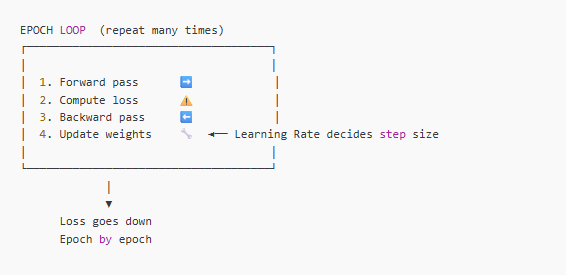

In [ ]:
# finindg the equation of the model after training the model and finding the weights and bias values.

performance_val = 2

years_of_experience_val = 10
projects_completed_val = 11
bonus_actual = 126 #( refer the dataset for this values)
predicted_bonus_test = w1.item() * performance_val + w2.item() * years_of_experience_val + w3.item() * projects_completed_val + bias.item()


print(f"Predicted Bonus: {predicted_bonus_test:0.2f}, Actual Bonus: {bonus_actual:0.2f}")





Predicted Bonus: 125.98, Actual Bonus: 126.00
